# Import statements and Loading the Dataset

In [ ]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.ensemble import IsolationForest
from sklearn.manifold import TSNE
from sklearn.feature_selection import SelectKBest,mutual_info_classif

from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import train_test_split, HalvingGridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.manifold import TSNE
from collections import Counter
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.tree import plot_tree
from scipy.stats import uniform

In [ ]:
path = kagglehub.dataset_download("kamilpytlak/personal-key-indicators-of-heart-disease/versions/6")

In [ ]:
dataset_path = kagglehub.dataset_download("kamilpytlak/personal-key-indicators-of-heart-disease/versions/6")
print("Dataset downloaded to:", dataset_path)

Dataset downloaded to: /root/.cache/kagglehub/datasets/kamilpytlak/personal-key-indicators-of-heart-disease/versions/6


In [ ]:
print("Files in dataset directory:", os.listdir(dataset_path))

Files in dataset directory: ['2020', '2022']


In [ ]:
dataset_2022_path = os.path.join(dataset_path, "2022")
print("Files in 2022 directory:", os.listdir(dataset_2022_path))

Files in 2022 directory: ['heart_2022_no_nans.csv', 'heart_2022_with_nans.csv']


In [ ]:
file_path = os.path.join(dataset_2022_path, "heart_2022_no_nans.csv")  # Adjust if the filename is different
df = pd.read_csv(file_path)

# Initial Data Cleaning

In [ ]:
data = df[df["Sex"] == "Female"]

In [ ]:
data = data.drop(columns=["State", "Sex", "HeightInMeters", "WeightInKilograms" , "RaceEthnicityCategory"])

# Data Exploratory Analysis

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 127811 entries, 0 to 246020
Data columns (total 40 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   State                      127811 non-null  object 
 1   Sex                        127811 non-null  object 
 2   GeneralHealth              127811 non-null  object 
 3   PhysicalHealthDays         127811 non-null  float64
 4   MentalHealthDays           127811 non-null  float64
 5   LastCheckupTime            127811 non-null  object 
 6   PhysicalActivities         127811 non-null  object 
 7   SleepHours                 127811 non-null  float64
 8   RemovedTeeth               127811 non-null  object 
 9   HadHeartAttack             127811 non-null  object 
 10  HadAngina                  127811 non-null  object 
 11  HadStroke                  127811 non-null  object 
 12  HadAsthma                  127811 non-null  object 
 13  HadSkinCancer              127811 

In [ ]:
data.describe()

,PhysicalHealthDays,MentalHealthDays,SleepHours,HeightInMeters,WeightInKilograms,BMI
count,127811.000000,127811.000000,127811.000000,127811.000000,127811.000000,127811.000000
mean,4.475374,4.881747,7.043212,1.634026,76.449821,28.619383
std,8.607564,8.562534,1.458613,0.074376,19.681955,7.054929
min,0.000000,0.000000,1.000000,0.910000,28.120000,12.020000
25%,0.000000,0.000000,6.000000,1.570000,62.600000,23.570000
50%,0.000000,0.000000,7.000000,1.630000,72.570000,27.440000
75%,4.000000,5.000000,8.000000,1.680000,86.180000,32.220000
max,30.000000,30.000000,24.000000,2.130000,263.080000,97.650000


In [ ]:
data.head()

,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadHeartAttack,...,HeightInMeters,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,Alabama,Female,Very good,4.0,0.0,Within past year (anytime less than 12 months ...,Yes,9.0,None of them,No,...,1.60,71.67,27.99,No,No,Yes,Yes,"Yes, received Tdap",No,No
3,Alabama,Female,Fair,5.0,0.0,Within past year (anytime less than 12 months ...,Yes,9.0,None of them,No,...,1.70,90.72,31.32,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,Yes
4,Alabama,Female,Good,3.0,15.0,Within past year (anytime less than 12 months ...,Yes,5.0,1 to 5,No,...,1.55,79.38,33.07,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No
6,Alabama,Female,Good,3.0,0.0,Within past year (anytime less than 12 months ...,Yes,8.0,"6 or more, but not all",No,...,1.63,88.00,33.30,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No
9,Alabama,Female,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,None of them,No,...,1.68,63.50,22.60,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No


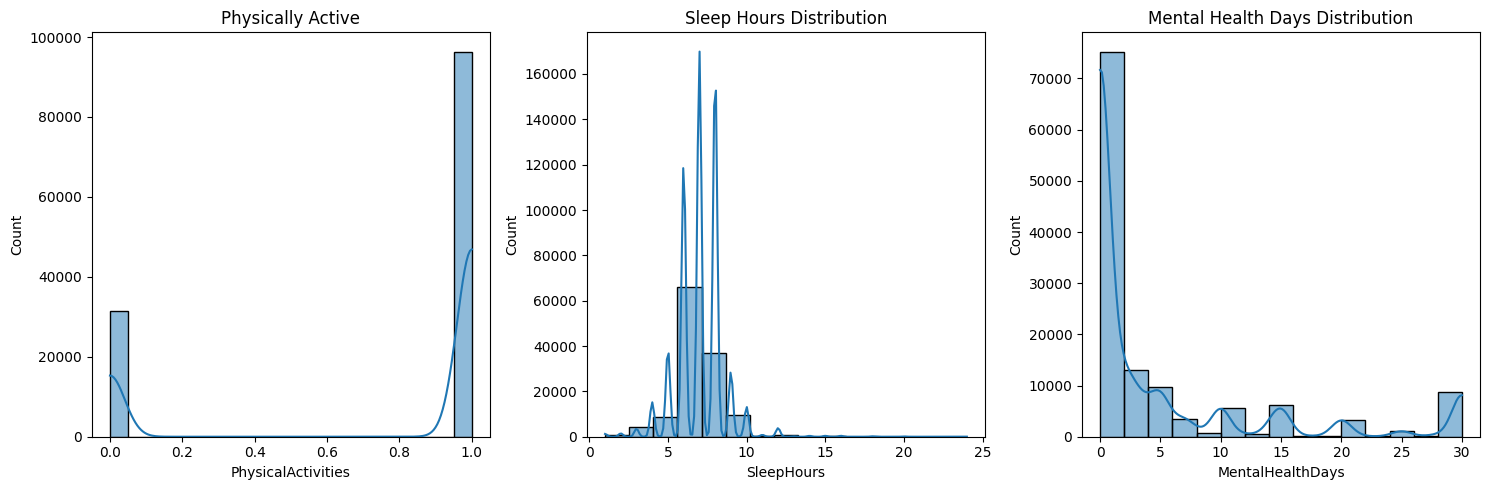

In [ ]:
# Plot distribution of BMI, Sleep, and Mental Health Days
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.histplot(data["PhysicalActivities"], bins=20, kde=True, ax=axes[0])
sns.histplot(data["SleepHours"], bins=15, kde=True, ax=axes[1])
sns.histplot(data["MentalHealthDays"], bins=15, kde=True, ax=axes[2])

axes[0].set_title("Physically Active")
axes[1].set_title("Sleep Hours Distribution")
axes[2].set_title("Mental Health Days Distribution")

plt.tight_layout()
plt.show()

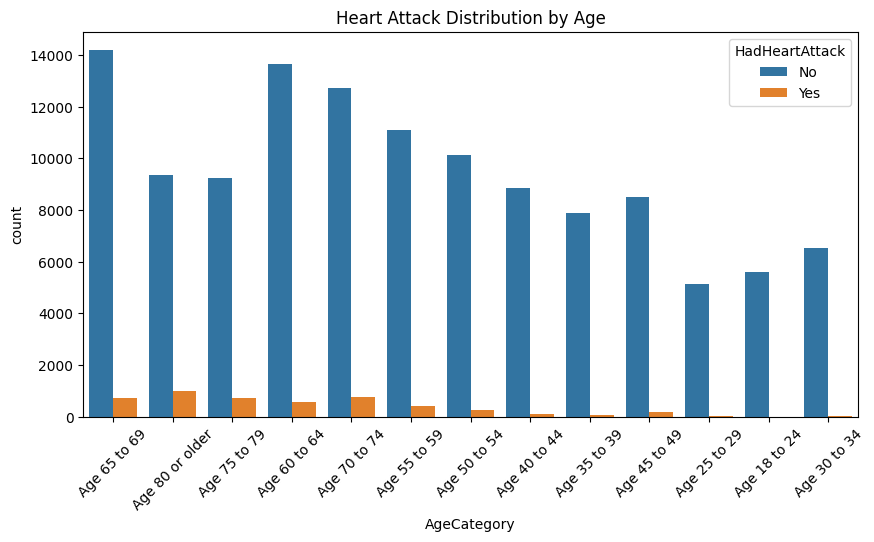

In [ ]:
plt.figure(figsize=(10, 5))
sns.countplot(x="AgeCategory", hue="HadHeartAttack", data=data)
plt.xticks(rotation=45)
plt.title("Heart Attack Distribution by Age")
plt.show()


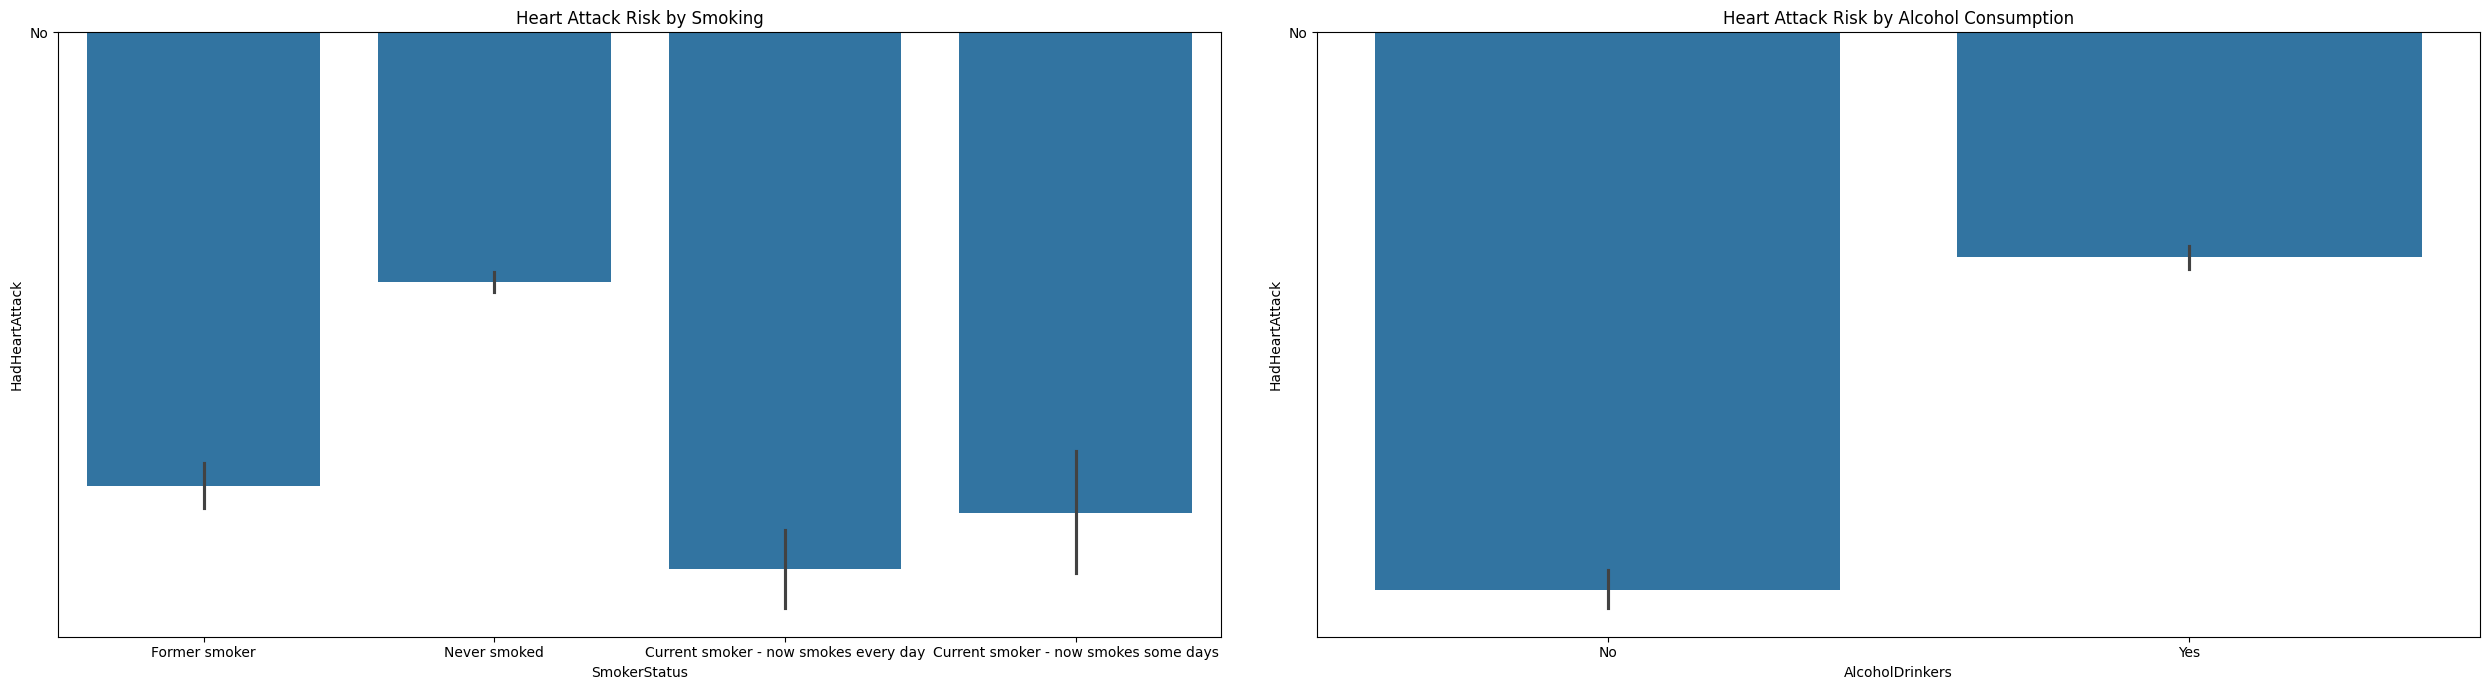

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(25, 7))

# Smoking impact
sns.barplot(x="SmokerStatus", y="HadHeartAttack", data=data, ax=axes[0])
axes[0].set_title("Heart Attack Risk by Smoking")

# Alcohol impact
sns.barplot(x="AlcoholDrinkers", y="HadHeartAttack", data=data, ax=axes[1])
axes[1].set_title("Heart Attack Risk by Alcohol Consumption")

plt.tight_layout()
plt.show()


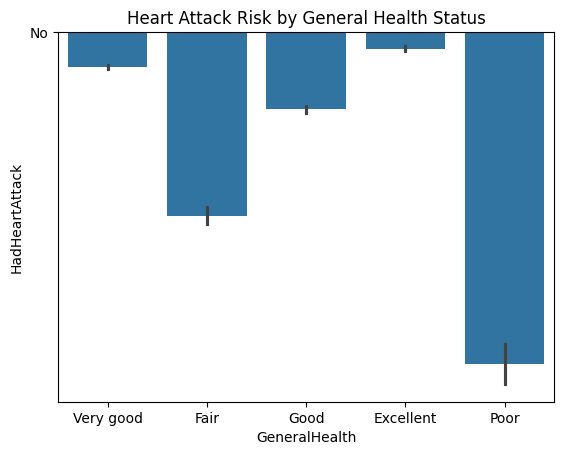

In [ ]:
sns.barplot(x="GeneralHealth", y="HadHeartAttack", data=data)
plt.title("Heart Attack Risk by General Health Status")
plt.show()


In [ ]:
data_encoded = pd.get_dummies(data, drop_first=True)

In [ ]:
data_encoded.head()

,PhysicalHealthDays,MentalHealthDays,SleepHours,HeightInMeters,WeightInKilograms,BMI,GeneralHealth_Fair,GeneralHealth_Good,GeneralHealth_Poor,GeneralHealth_Very good,...,AlcoholDrinkers_Yes,HIVTesting_Yes,FluVaxLast12_Yes,PneumoVaxEver_Yes,"TetanusLast10Tdap_Yes, received Tdap","TetanusLast10Tdap_Yes, received tetanus shot but not sure what type","TetanusLast10Tdap_Yes, received tetanus shot, but not Tdap",HighRiskLastYear_Yes,CovidPos_Tested positive using home test without a health professional,CovidPos_Yes
0,4.0,0.0,9.0,1.60,71.67,27.99,False,False,False,True,...,False,False,True,True,True,False,False,False,False,False
3,5.0,0.0,9.0,1.70,90.72,31.32,True,False,False,False,...,False,False,True,True,False,False,False,False,False,True
4,3.0,15.0,5.0,1.55,79.38,33.07,False,True,False,False,...,False,False,True,True,False,False,False,False,False,False
6,3.0,0.0,8.0,1.63,88.00,33.30,False,True,False,False,...,False,False,True,True,False,False,False,False,False,False
9,0.0,0.0,7.0,1.68,63.50,22.60,False,False,False,True,...,False,False,True,True,False,False,False,False,False,False


In [ ]:
columns_for_Correlation = data_encoded[["BMI", "PhysicalHealthDays", "MentalHealthDays", "SleepHours","HadHeartAttack_Yes"]]

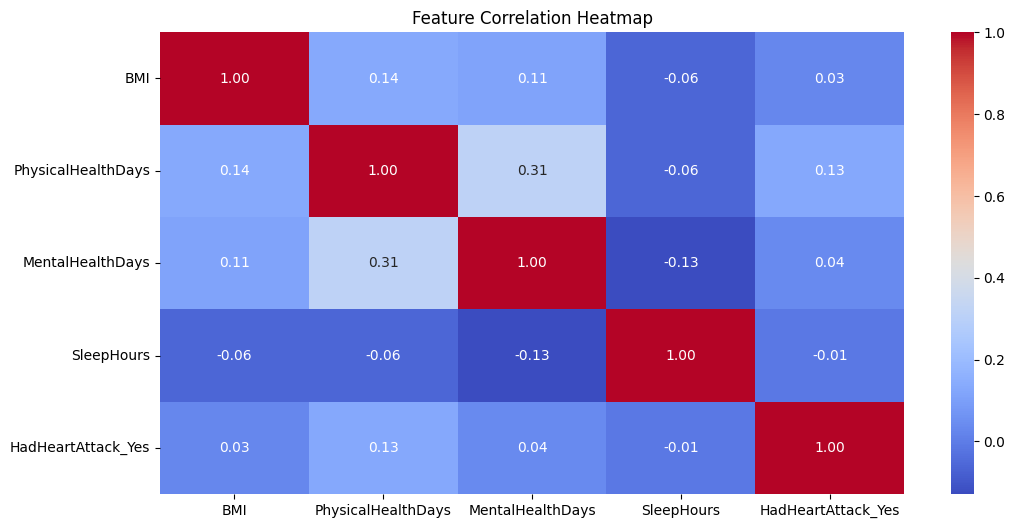

In [ ]:
plt.figure(figsize=(12, 6))
sns.heatmap(columns_for_Correlation.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

# Preprocessing
1. converts the categorical and scales the numerical
2. Outlier detection


In [ ]:
binary_Cols = [ "PhysicalActivities",
"HadHeartAttack",
"HadAngina",
"HadStroke",
"HadAsthma",
"HadCOPD",
"HadDepressiveDisorder",
"HadKidneyDisease",
"HadArthritis",
"DeafOrHardOfHearing",
"BlindOrVisionDifficulty",
"DifficultyConcentrating",
"DifficultyWalking",
"DifficultyDressingBathing",
"DifficultyErrands",
"ChestScan",
"AlcoholDrinkers",
"HIVTesting",
"FluVaxLast12",
"PneumoVaxEver",
"HighRiskLastYear"]

In [ ]:
label_encoder = LabelEncoder()

for column in binary_Cols:
    data[column] = label_encoder.fit_transform(data[column])

In [ ]:
cats = data.select_dtypes(include=['object']).columns.to_list()
nums = data.select_dtypes(include=['float64']).columns.to_list()

In [ ]:
nums

['PhysicalHealthDays', 'MentalHealthDays', 'SleepHours', 'BMI']

In [ ]:
cats

['GeneralHealth',
 'LastCheckupTime',
 'RemovedTeeth',
 'HadSkinCancer',
 'HadDiabetes',
 'SmokerStatus',
 'ECigaretteUsage',
 'AgeCategory',
 'TetanusLast10Tdap',
 'CovidPos']

In [ ]:
binary_Cols

['PhysicalActivities',
 'HadHeartAttack',
 'HadAngina',
 'HadStroke',
 'HadAsthma',
 'HadCOPD',
 'HadDepressiveDisorder',
 'HadKidneyDisease',
 'HadArthritis',
 'DeafOrHardOfHearing',
 'BlindOrVisionDifficulty',
 'DifficultyConcentrating',
 'DifficultyWalking',
 'DifficultyDressingBathing',
 'DifficultyErrands',
 'ChestScan',
 'AlcoholDrinkers',
 'HIVTesting',
 'FluVaxLast12',
 'PneumoVaxEver',
 'HighRiskLastYear']

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), nums),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cats)
    ],
    remainder='passthrough'  # Pass through binary columns without transformation
)

# Apply the transformation
df = preprocessor.fit_transform(data)

# Get column names
ohe_columns = preprocessor.transformers_[0][1].get_feature_names_out()
num_cols =  preprocessor.transformers_[1][1].get_feature_names_out()
all_cols = list(ohe_columns) + list(num_cols) + binary_Cols

# Create the final DataFrame
processed_df = pd.DataFrame(df, columns=all_cols)

In [ ]:
processed_df

,PhysicalHealthDays,MentalHealthDays,SleepHours,BMI,GeneralHealth_Excellent,GeneralHealth_Fair,GeneralHealth_Good,GeneralHealth_Poor,GeneralHealth_Very good,LastCheckupTime_5 or more years ago,...,DifficultyConcentrating,DifficultyWalking,DifficultyDressingBathing,DifficultyErrands,ChestScan,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,HighRiskLastYear
0,0.133333,0.000000,0.347826,0.186500,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
1,0.166667,0.000000,0.347826,0.225388,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
2,0.100000,0.500000,0.173913,0.245825,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
3,0.100000,0.000000,0.304348,0.248511,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
4,0.000000,0.000000,0.260870,0.123555,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127806,0.000000,0.000000,0.304348,0.126241,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
127807,0.000000,0.000000,0.478261,0.083148,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
127808,0.000000,0.000000,0.260870,0.190004,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
127809,0.000000,0.233333,0.260870,0.143875,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Pipeline has not been used for the entire dataset


In [ ]:
class OutlierRemover(BaseEstimator, TransformerMixin):
    def __init__(self, contamination=0.1):
        self.contamination = contamination
        self.isolation_forest = IsolationForest(contamination=self.contamination)

    def fit(self, X, y=None):
        self.isolation_forest.fit(X)
        return self

    def transform(self, X):
        # Predict outliers and filter them out
        outliers = self.isolation_forest.predict(X)  # -1 for outliers, 1 for inliers
        return X[outliers == 1]

outlier = Pipeline(steps=[
    ('outlier_remover', OutlierRemover(contamination=0.1))  # Custom outlier removal step,

])

In [ ]:
data_new = outlier.fit_transform(processed_df)

In [ ]:
data_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 115030 entries, 0 to 127810
Data columns (total 72 columns):
 #   Column                                                                       Non-Null Count   Dtype  
---  ------                                                                       --------------   -----  
 0   PhysicalHealthDays                                                           115030 non-null  float64
 1   MentalHealthDays                                                             115030 non-null  float64
 2   SleepHours                                                                   115030 non-null  float64
 3   BMI                                                                          115030 non-null  float64
 4   GeneralHealth_Excellent                                                      115030 non-null  float64
 5   GeneralHealth_Fair                                                           115030 non-null  float64
 6   GeneralHealth_Good               

In [ ]:
# Determine X and y
X = data_new.drop('HadHeartAttack', axis=1)
y = data_new['HadHeartAttack']
# Check the numbers

y.value_counts()

,count
HadHeartAttack,
0.0,112521
1.0,2509


Severe Imbalance noted

# KBEST

In [ ]:
kbest_model = SelectKBest(mutual_info_classif, k=15)

In [ ]:
kbest_model.fit(X, y)

SelectKBest(k=15, score_func=<function mutual_info_classif at 0x79633b710860>)

In [ ]:
kbest_model.get_feature_names_out()

array(['GeneralHealth_Very good',
       'LastCheckupTime_Within past year (anytime less than 12 months ago)',
       'RemovedTeeth_None of them', 'HadSkinCancer_No', 'HadDiabetes_No',
       'SmokerStatus_Never smoked',
       'ECigaretteUsage_Never used e-cigarettes in my entire life',
       'CovidPos_No', 'PhysicalActivities', 'HadAngina', 'HadArthritis',
       'ChestScan', 'AlcoholDrinkers', 'FluVaxLast12', 'PneumoVaxEver'],
      dtype=object)

In [ ]:
k_best_indices = kbest_model.get_support(indices=True)

k_best_features = X.columns[k_best_indices]

X_kbest = X[k_best_features]


# PCA

In [ ]:
from sklearn.decomposition import PCA
pca = PCA()

# Fit PCA on the scaled data
pca.fit(X)

# Transform the data
X_pca = pca.transform(X)

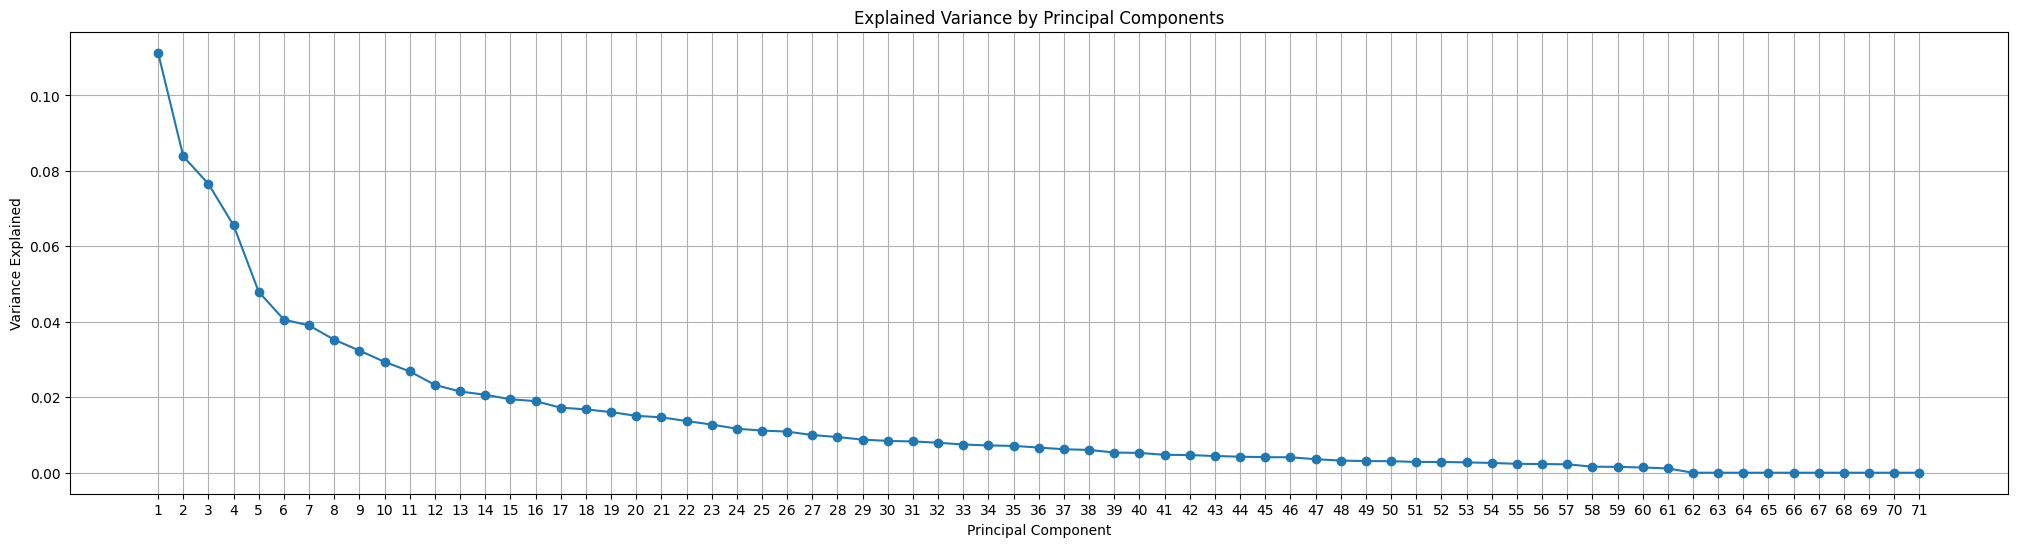

In [ ]:
# Plot explained variance
plt.figure(figsize=(25, 6))
plt.plot(range(1, X.shape[1] + 1), pca.explained_variance_ratio_, marker='o')
plt.title('Explained Variance by Principal Components')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.xticks(range(1, X.shape[1] + 1))
plt.grid()
plt.show()

In [ ]:
# Initialize PCA with a specific number of components
n_components = 6  # Choose the number of components you want to keep
pca = PCA(n_components=n_components)

# Fit and transform the data
X_pca = pca.fit_transform(X)

## PCA VISUALIZATION

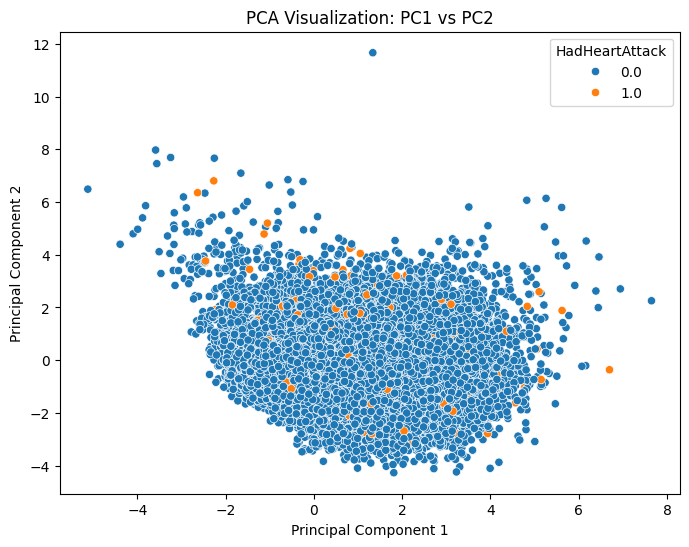

In [ ]:
X_pca_df = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])  # Create DataFrame
X_pca_df['HadHeartAttack'] = y.values # add the target column
# Now you can use the DataFrame with sns.scatterplot
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PC1', y='PC2', hue='HadHeartAttack', data=X_pca_df) # Use DataFrame here
plt.title('PCA Visualization: PC1 vs PC2')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

# TSNE

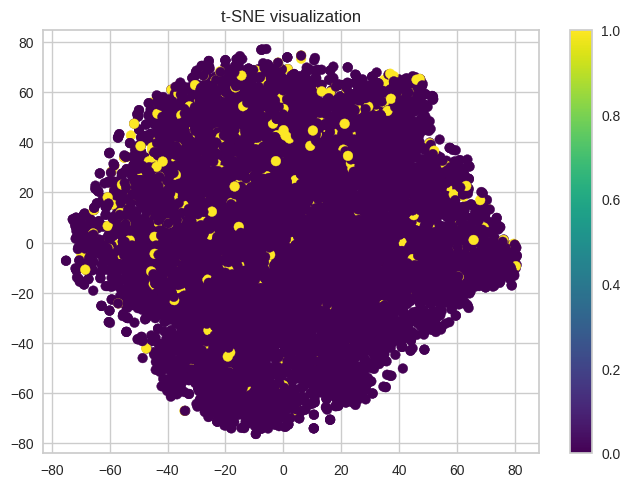

In [ ]:
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X)
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='viridis')
plt.title('t-SNE visualization')
plt.colorbar()
plt.show()


# CLASSIFICATION

## FUNCTIONS

In [ ]:

def regular_split(X, y, test_size=0.2, random_state=42):
  return train_test_split(X, y, test_size=test_size, stratify = y,  random_state=random_state)

def balanced_split(X, y, test_size=0.2, random_state=42):
    class_counts = Counter(y)
    min_class_size = min(class_counts.values())
    class_indices = {label: np.where(y == label)[0] for label in class_counts}
    balanced_indices = []
    for label, indices in class_indices.items():
        balanced_indices.extend(np.random.choice(indices, min_class_size, replace=False))
    if isinstance(X, np.ndarray):
        X = pd.DataFrame(X)
    X_balanced, y_balanced = X.iloc[balanced_indices], y.iloc[balanced_indices]



    return train_test_split(X_balanced, y_balanced, test_size=test_size, random_state=random_state, stratify=y_balanced)


In [ ]:

def fit_best_model(X_CV_temp, y_CV_temp, X_train, y_train, X_test, y_test):
    # Define models with class balancing
    dt = DecisionTreeClassifier(random_state=42, class_weight="balanced")
    rf = RandomForestClassifier(random_state=42, class_weight="balanced")
    lr = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")

    # Define hyperparameter grids
    dt_params = {
        'criterion': ['gini', 'entropy'],
        'splitter': ['best', 'random'],
        'ccp_alpha': uniform(0.0, 0.02).rvs(10)  # Generate 10 values from the distribution
    }

    rf_params = {
        'n_estimators': [50, 100, 200, 300],
        'max_features': ['sqrt', 'log2', None],
    }

    lr_params = {
        'penalty': ['l1', 'l2', 'elasticnet', None],
        'C': uniform(0.001, 10).rvs(5),
        'max_iter': [100, 200],
        'solver': ['liblinear', 'saga'],
    }

    # Hyperparameter tuning using HalvingGridSearchCV on X_CV_temp, y_CV_temp
    dt_search = HalvingGridSearchCV(dt, dt_params, cv=5, factor=2, random_state=42, verbose=1)
    rf_search = HalvingGridSearchCV(rf, rf_params, cv=5, factor=2, random_state=42, verbose=1)
    lr_search = HalvingGridSearchCV(lr, lr_params, cv=5, factor=2, random_state=42, verbose=1)

    dt_search.fit(X_CV_temp, y_CV_temp)
    rf_search.fit(X_CV_temp, y_CV_temp)
    lr_search.fit(X_CV_temp, y_CV_temp)

    # Retrieve best hyperparameters
    best_dt_params = dt_search.best_params_
    best_rf_params = rf_search.best_params_
    best_lr_params = lr_search.best_params_

    print("Best Decision Tree Hyperparameters:", best_dt_params)
    print("Best Random Forest Hyperparameters:", best_rf_params)
    print("Best Logistic Regression Hyperparameters:", best_lr_params)

    # Train new models on full X_train, y_train using best hyperparameters
    best_dt = DecisionTreeClassifier(random_state=42, class_weight="balanced", **best_dt_params)
    best_rf = RandomForestClassifier(random_state=42, class_weight="balanced", **best_rf_params)
    best_lr = LogisticRegression(random_state=42, class_weight="balanced", **best_lr_params)

    best_dt.fit(X_train, y_train)
    best_rf.fit(X_train, y_train)
    best_lr.fit(X_train, y_train)

    # Predictions
    y_pred_dt = best_dt.predict(X_test)
    y_pred_rf = best_rf.predict(X_test)
    y_pred_lr = best_lr.predict(X_test)

    # Store models and predictions
    models = {
        "Decision Tree": (y_pred_dt, best_dt),
        "Random Forest": (y_pred_rf, best_rf),
        "Logistic Regression": (y_pred_lr, best_lr),
    }

    return models

In [ ]:

def evaluate_models(models, X_test, y_test):

    results = []
    for name, (y_pred, model) in models.items():
        results.append({
            "Model": name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred, average="weighted"),
            "Recall": recall_score(y_test, y_pred, average="weighted"),
            "F1-Score": f1_score(y_test, y_pred, average="weighted"),
        })

    results_df = pd.DataFrame(results)
    print("\nModel Scores:\n", results_df)
    return results_df


def compute_confusion_matrices(models, y_test):

    conf_matrices = {name: confusion_matrix(y_test, y_pred) for name, (y_pred, _) in models.items()}

    # Concatenating confusion matrices for better visualization
    conf_matrix_df = pd.concat(
        [pd.DataFrame(conf_matrices[name],
                      index=[f"{name} Actual {i}" for i in range(len(conf_matrices[name]))],
                      columns=[f"{name} Pred {i}" for i in range(len(conf_matrices[name]))])
         for name in conf_matrices], axis=1)

    print("\nConfusion Matrices:\n", conf_matrix_df)
    return conf_matrices


def display_classification_reports(models, y_test):

    for name, (y_pred, _) in models.items():
        print(f"\nClassification Report for {name}:\n", classification_report(y_test, y_pred))


def visualize_decision_tree(best_dt, feature_names):

    plt.figure(figsize=(12, 6))
    plot_tree(best_dt, feature_names=feature_names, class_names=['No', 'Yes'], filled=True)
    plt.title("Decision Tree Visualization")
    plt.show()

def extract_top_features(model, feature_names, top_n=2):

    if hasattr(model, "feature_importances_"):  # For tree-based models like DecisionTree and RandomForest
        importances = model.feature_importances_
    elif hasattr(model, "coef_"):  # For models like Logistic Regression
        importances = np.abs(model.coef_).flatten()
    else:
        return []

    # Return the top N features (sorted by importance)
    return [feature_names[i] for i in np.argsort(importances)[-top_n:]]




## CLASSIFICATION ON THE KBEST

In [ ]:
X_train, X_test, y_train, y_test = regular_split(X_kbest, y)
X_CV_temp, X_CV, y_CV_temp, y_CV = balanced_split(X_train, y_train)

In [ ]:
models = fit_best_model(X_CV_temp, y_CV_temp, X_train, y_train, X_test, y_test)

n_iterations: 6
n_required_iterations: 6
n_possible_iterations: 6
min_resources_: 114
max_resources_: 3651
aggressive_elimination: False
factor: 2
----------
iter: 0
n_candidates: 40
n_resources: 114
Fitting 5 folds for each of 40 candidates, totalling 200 fits
----------
iter: 1
n_candidates: 20
n_resources: 228
Fitting 5 folds for each of 20 candidates, totalling 100 fits
----------
iter: 2
n_candidates: 10
n_resources: 456
Fitting 5 folds for each of 10 candidates, totalling 50 fits
----------
iter: 3
n_candidates: 5
n_resources: 912
Fitting 5 folds for each of 5 candidates, totalling 25 fits
----------
iter: 4
n_candidates: 3
n_resources: 1824
Fitting 5 folds for each of 3 candidates, totalling 15 fits
----------
iter: 5
n_candidates: 2
n_resources: 3648
Fitting 5 folds for each of 2 candidates, totalling 10 fits
n_iterations: 4
n_required_iterations: 4
n_possible_iterations: 4
min_resources_: 456
max_resources_: 3651
aggressive_elimination: False
factor: 2
----------
iter: 0
n_can

In [ ]:
results_df = evaluate_models(models, X_test, y_test)


Model Scores:
                  Model  Accuracy  Precision    Recall  F1-Score
0        Decision Tree  0.641050   0.969513  0.641050  0.759025
1        Random Forest  0.848257   0.960992  0.848257  0.897295
2  Logistic Regression  0.751891   0.963563  0.751891  0.837376


In [ ]:
conf_matrices = compute_confusion_matrices(models, y_test)


Confusion Matrices:
                               Decision Tree Pred 0  Decision Tree Pred 1  \
Decision Tree Actual 0                     14282.0                8154.0   
Decision Tree Actual 1                       104.0                 466.0   
Random Forest Actual 0                         NaN                   NaN   
Random Forest Actual 1                         NaN                   NaN   
Logistic Regression Actual 0                   NaN                   NaN   
Logistic Regression Actual 1                   NaN                   NaN   

                              Random Forest Pred 0  Random Forest Pred 1  \
Decision Tree Actual 0                         NaN                   NaN   
Decision Tree Actual 1                         NaN                   NaN   
Random Forest Actual 0                     19267.0                3169.0   
Random Forest Actual 1                       322.0                 248.0   
Logistic Regression Actual 0                   NaN               

In [ ]:
display_classification_reports(models, y_test)


Classification Report for Decision Tree:
               precision    recall  f1-score   support

         0.0       0.99      0.64      0.78     22436
         1.0       0.05      0.82      0.10       570

    accuracy                           0.64     23006
   macro avg       0.52      0.73      0.44     23006
weighted avg       0.97      0.64      0.76     23006


Classification Report for Random Forest:
               precision    recall  f1-score   support

         0.0       0.98      0.86      0.92     22436
         1.0       0.07      0.44      0.12       570

    accuracy                           0.85     23006
   macro avg       0.53      0.65      0.52     23006
weighted avg       0.96      0.85      0.90     23006


Classification Report for Logistic Regression:
               precision    recall  f1-score   support

         0.0       0.99      0.76      0.86     22436
         1.0       0.06      0.59      0.11       570

    accuracy                           0.75    

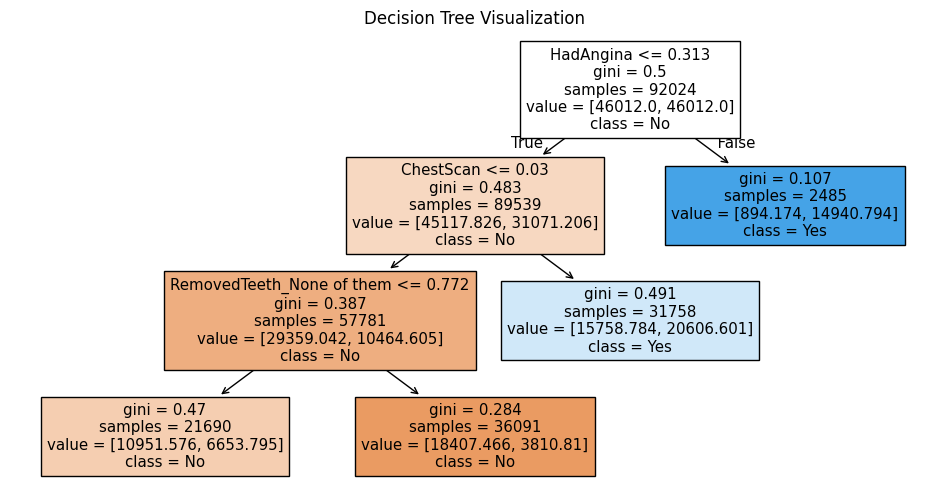

In [ ]:
visualize_decision_tree(models["Decision Tree"][1], X_test.columns)

In [ ]:

top_features = {
    name: extract_top_features(model, X.columns)
    for name, (_, model) in models.items()
}

print("\nTop 2 Features for Each Model:\n", top_features)



Top 2 Features for Each Model:
 {'Decision Tree': ['LastCheckupTime_Within past 5 years (2 years but less than 5 years ago)', 'LastCheckupTime_5 or more years ago'], 'Random Forest': ['LastCheckupTime_Within past 5 years (2 years but less than 5 years ago)', 'LastCheckupTime_5 or more years ago'], 'Logistic Regression': ['LastCheckupTime_Within past 5 years (2 years but less than 5 years ago)', 'LastCheckupTime_5 or more years ago']}


## CLASSFICATION ON PCA

In [ ]:
X_train, X_test, y_train, y_test = regular_split(X_pca, y)

In [ ]:
X_CV_temp, X_CV, y_CV_temp, y_CV = balanced_split(X_train, y_train)

In [ ]:
models = fit_best_model(X_CV_temp, y_CV_temp, X_train, y_train, X_test, y_test)

n_iterations: 6
n_required_iterations: 6
n_possible_iterations: 6
min_resources_: 114
max_resources_: 3651
aggressive_elimination: False
factor: 2
----------
iter: 0
n_candidates: 40
n_resources: 114
Fitting 5 folds for each of 40 candidates, totalling 200 fits
----------
iter: 1
n_candidates: 20
n_resources: 228
Fitting 5 folds for each of 20 candidates, totalling 100 fits
----------
iter: 2
n_candidates: 10
n_resources: 456
Fitting 5 folds for each of 10 candidates, totalling 50 fits
----------
iter: 3
n_candidates: 5
n_resources: 912
Fitting 5 folds for each of 5 candidates, totalling 25 fits
----------
iter: 4
n_candidates: 3
n_resources: 1824
Fitting 5 folds for each of 3 candidates, totalling 15 fits
----------
iter: 5
n_candidates: 2
n_resources: 3648
Fitting 5 folds for each of 2 candidates, totalling 10 fits
n_iterations: 4
n_required_iterations: 4
n_possible_iterations: 4
min_resources_: 456
max_resources_: 3651
aggressive_elimination: False
factor: 2
----------
iter: 0
n_can

In [ ]:
results_df = evaluate_models(models, X_test, y_test)


Model Scores:
                  Model  Accuracy  Precision    Recall  F1-Score
0        Decision Tree  0.585065   0.963558  0.585065  0.716142
1        Random Forest  0.975224   0.951062  0.975224  0.962991
2  Logistic Regression  0.670521   0.965124  0.670521  0.781191


In [ ]:
conf_matrices = compute_confusion_matrices(models, y_test)


Confusion Matrices:
                               Decision Tree Pred 0  Decision Tree Pred 1  \
Decision Tree Actual 0                     13062.0                9374.0   
Decision Tree Actual 1                       172.0                 398.0   
Random Forest Actual 0                         NaN                   NaN   
Random Forest Actual 1                         NaN                   NaN   
Logistic Regression Actual 0                   NaN                   NaN   
Logistic Regression Actual 1                   NaN                   NaN   

                              Random Forest Pred 0  Random Forest Pred 1  \
Decision Tree Actual 0                         NaN                   NaN   
Decision Tree Actual 1                         NaN                   NaN   
Random Forest Actual 0                     22436.0                   0.0   
Random Forest Actual 1                       570.0                   0.0   
Logistic Regression Actual 0                   NaN               

In [ ]:
display_classification_reports(models, y_test)


Classification Report for Decision Tree:
               precision    recall  f1-score   support

         0.0       0.99      0.58      0.73     22436
         1.0       0.04      0.70      0.08       570

    accuracy                           0.59     23006
   macro avg       0.51      0.64      0.40     23006
weighted avg       0.96      0.59      0.72     23006


Classification Report for Random Forest:
               precision    recall  f1-score   support

         0.0       0.98      1.00      0.99     22436
         1.0       0.00      0.00      0.00       570

    accuracy                           0.98     23006
   macro avg       0.49      0.50      0.49     23006
weighted avg       0.95      0.98      0.96     23006


Classification Report for Logistic Regression:
               precision    recall  f1-score   support

         0.0       0.99      0.67      0.80     22436
         1.0       0.05      0.69      0.09       570

    accuracy                           0.67    

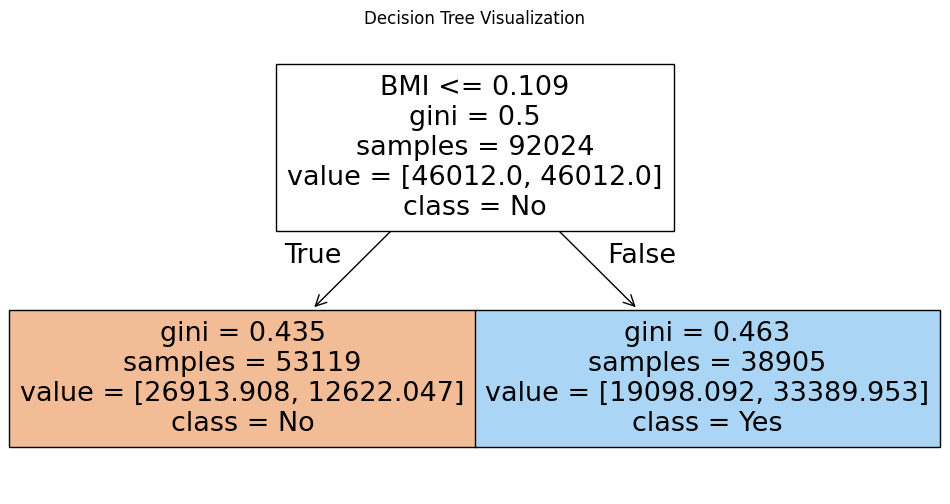

In [ ]:
visualize_decision_tree(models["Decision Tree"][1], X.columns)

In [ ]:

top_features = {
    name: extract_top_features(model, X.columns)
    for name, (_, model) in models.items()
}

print("\nTop 2 Features for Each Model:\n", top_features)



Top 2 Features for Each Model:
 {'Decision Tree': ['GeneralHealth_Fair', 'BMI'], 'Random Forest': ['GeneralHealth_Excellent', 'BMI'], 'Logistic Regression': ['GeneralHealth_Excellent', 'BMI']}


# SVM

In [ ]:
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE


## SVM PCA

In [ ]:
param_svc = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'degree': [2, 3, 4],
    'decision_function_shape': ['ovo', 'ovr'],
    'class_weight': [None, 'balanced']
}

In [ ]:
hscv_svc = HalvingGridSearchCV(SVC(), param_svc, scoring='accuracy', refit=True, cv=5, verbose=3)


In [ ]:
hscv_svc.fit(X_train, y_train)



In [ ]:
hscv_svc.fit(X_train, y_train)


n_iterations: 5
n_required_iterations: 5
n_possible_iterations: 5
min_resources_: 840
max_resources_: 68068
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 144
n_resources: 840
Fitting 5 folds for each of 144 candidates, totalling 720 fits
[CV 1/5] END C=0.1, class_weight=None, decision_function_shape=ovo, degree=2, kernel=linear;, score=(train=0.724, test=0.750) total time=   0.0s
[CV 2/5] END C=0.1, class_weight=None, decision_function_shape=ovo, degree=2, kernel=linear;, score=(train=0.748, test=0.708) total time=   0.0s
[CV 3/5] END C=0.1, class_weight=None, decision_function_shape=ovo, degree=2, kernel=linear;, score=(train=0.700, test=0.726) total time=   0.0s
[CV 4/5] END C=0.1, class_weight=None, decision_function_shape=ovo, degree=2, kernel=linear;, score=(train=0.726, test=0.754) total time=   0.0s
[CV 5/5] END C=0.1, class_weight=None, decision_function_shape=ovo, degree=2, kernel=linear;, score=(train=0.708, test=0.725) total time=   0.0s
[CV 1/5] E

HalvingGridSearchCV(estimator=SVC(),
                    param_grid={'C': [0.1, 1, 10],
                                'class_weight': [None, 'balanced'],
                                'decision_function_shape': ['ovo', 'ovr'],
                                'degree': [2, 3, 4],
                                'kernel': ['linear', 'poly', 'rbf', 'sigmoid']},
                    scoring='accuracy', verbose=3)

In [ ]:
best_svc = hscv_svc.best_estimator_
svc_pred_test = best_svc.predict(X_test)

In [ ]:
print("SVM Classification Report:")
print(classification_report(y_test, svc_pred_test))


SVM Classification Report:
              precision    recall  f1-score   support

         0.0       0.99      0.69      0.81     14586
         1.0       0.07      0.69      0.12       462

    accuracy                           0.69     15048
   macro avg       0.53      0.69      0.47     15048
weighted avg       0.96      0.69      0.79     15048



In [ ]:
print("Confusion Matrix - SVM")
cm_svm=confusion_matrix(y_test, svc_pred_test)
print(cm_svm)

Confusion Matrix - SVM
[[10112  4474]
 [  144   318]]


side note --> The title is incorrect - this is for SVM

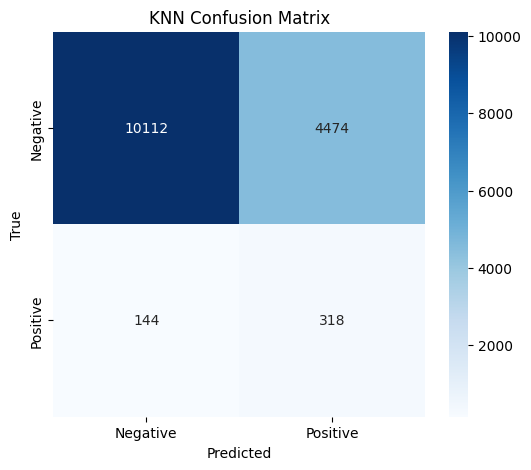

In [ ]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('SVM Confusion Matrix')
plt.show()

## SVM - KBEST

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_kbest, y, test_size=0.3, random_state=42, stratify=y)

In [ ]:
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

In [ ]:
param_svc = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'degree': [2, 3, 4],
    'decision_function_shape': ['ovo', 'ovr'],
    'class_weight': [None, 'balanced']
}

In [ ]:
hscv_svc = HalvingGridSearchCV(SVC(), param_svc, scoring='accuracy', refit=True, cv=2, verbose=3)
hscv_svc.fit(X_train, y_train)


n_iterations: 5
n_required_iterations: 5
n_possible_iterations: 5
min_resources_: 2828
max_resources_: 229130
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 144
n_resources: 2828
Fitting 2 folds for each of 144 candidates, totalling 288 fits
[CV 1/2] END C=0.1, class_weight=None, decision_function_shape=ovo, degree=2, kernel=linear;, score=(train=0.750, test=0.762) total time=   0.1s
[CV 2/2] END C=0.1, class_weight=None, decision_function_shape=ovo, degree=2, kernel=linear;, score=(train=0.765, test=0.751) total time=   0.1s
[CV 1/2] END C=0.1, class_weight=None, decision_function_shape=ovo, degree=2, kernel=poly;, score=(train=0.760, test=0.760) total time=   0.1s
[CV 2/2] END C=0.1, class_weight=None, decision_function_shape=ovo, degree=2, kernel=poly;, score=(train=0.772, test=0.748) total time=   0.1s
[CV 1/2] END C=0.1, class_weight=None, decision_function_shape=ovo, degree=2, kernel=rbf;, score=(train=0.761, test=0.767) total time=   0.2s
[CV 2/2] END C

HalvingGridSearchCV(cv=2, estimator=SVC(),
                    param_grid={'C': [0.1, 1, 10],
                                'class_weight': [None, 'balanced'],
                                'decision_function_shape': ['ovo', 'ovr'],
                                'degree': [2, 3, 4],
                                'kernel': ['linear', 'poly', 'rbf', 'sigmoid']},
                    scoring='accuracy', verbose=3)

In [ ]:
best_svc = hscv_svc.best_estimator_
svc_pred_test = best_svc.predict(X_test)

In [ ]:
print("SVM Classification Report:")
print(classification_report(y_test, svc_pred_test))


SVM Classification Report:
              precision    recall  f1-score   support

         0.0       0.98      0.93      0.96     49100
         1.0       0.16      0.39      0.22      1526

    accuracy                           0.92     50626
   macro avg       0.57      0.66      0.59     50626
weighted avg       0.96      0.92      0.93     50626



In [ ]:
print("Confusion Matrix - SVM")
cm_svm=confusion_matrix(y_test, svc_pred_test)
print(cm_svm)

Confusion Matrix - SVM
[[45822  3278]
 [  924   602]]


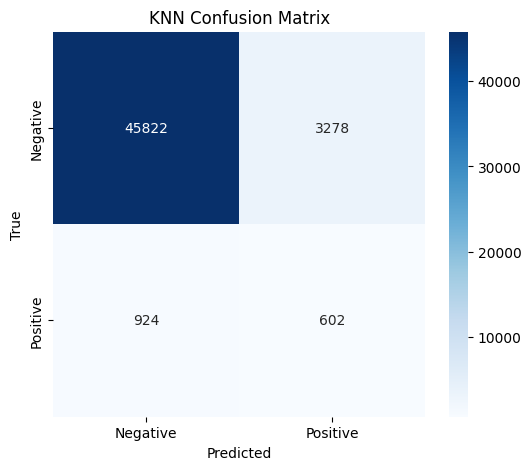

In [ ]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('KNN Confusion Matrix')
plt.show()

# KNN

## KNN - PCA

In [ ]:
param_knn = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}


In [ ]:
# Halving Grid Search for KNN
hscv_knn = HalvingGridSearchCV(KNeighborsClassifier(), param_knn, factor=2, scoring='accuracy', refit=True, cv=5, verbose=3)
hscv_knn.fit(X_train, y_train)



n_iterations: 5
n_required_iterations: 5
n_possible_iterations: 5
min_resources_: 4254
max_resources_: 68068
aggressive_elimination: False
factor: 2
----------
iter: 0
n_candidates: 20
n_resources: 4254
Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV 1/5] END metric=euclidean, n_neighbors=3, weights=uniform;, score=(train=0.882, test=0.773) total time=   0.0s
[CV 2/5] END metric=euclidean, n_neighbors=3, weights=uniform;, score=(train=0.880, test=0.765) total time=   0.1s
[CV 3/5] END metric=euclidean, n_neighbors=3, weights=uniform;, score=(train=0.888, test=0.760) total time=   0.0s
[CV 4/5] END metric=euclidean, n_neighbors=3, weights=uniform;, score=(train=0.881, test=0.778) total time=   0.0s
[CV 5/5] END metric=euclidean, n_neighbors=3, weights=uniform;, score=(train=0.880, test=0.796) total time=   0.0s
[CV 1/5] END metric=euclidean, n_neighbors=3, weights=distance;, score=(train=1.000, test=0.786) total time=   0.0s
[CV 2/5] END metric=euclidean, n_neighbors=3

HalvingGridSearchCV(estimator=KNeighborsClassifier(), factor=2,
                    param_grid={'metric': ['euclidean', 'manhattan'],
                                'n_neighbors': [3, 5, 7, 9, 11],
                                'weights': ['uniform', 'distance']},
                    scoring='accuracy', verbose=3)

In [ ]:
# Best KNN model
best_knn = hscv_knn.best_estimator_
knn_pred_test = best_knn.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report
print("KNN Classification Report:")
print(classification_report(y_test, knn_pred_test))

KNN Classification Report:
              precision    recall  f1-score   support

         0.0       0.97      0.88      0.93     14586
         1.0       0.07      0.28      0.11       462

    accuracy                           0.86     15048
   macro avg       0.52      0.58      0.52     15048
weighted avg       0.95      0.86      0.90     15048



In [ ]:
print("KNN Confusion Matrix:")
cm=confusion_matrix(y_test, knn_pred_test)
print(cm)

KNN Confusion Matrix:
[[12872  1714]
 [  334   128]]


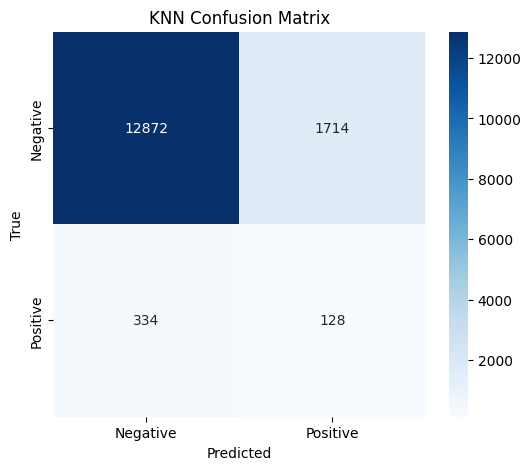

In [ ]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('KNN Confusion Matrix')
plt.show()

## KNN - KBEST

In [ ]:
param_knn = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

In [ ]:
hscv_knn = HalvingGridSearchCV(KNeighborsClassifier(), param_knn, factor=2, scoring='accuracy', refit=True, cv=5, verbose=3)
hscv_knn.fit(X_train, y_train)


n_iterations: 5
n_required_iterations: 5
n_possible_iterations: 5
min_resources_: 14320
max_resources_: 229130
aggressive_elimination: False
factor: 2
----------
iter: 0
n_candidates: 20
n_resources: 14320
Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV 1/5] END metric=euclidean, n_neighbors=3, weights=uniform;, score=(train=0.875, test=0.798) total time=   0.5s
[CV 2/5] END metric=euclidean, n_neighbors=3, weights=uniform;, score=(train=0.885, test=0.808) total time=   0.5s
[CV 3/5] END metric=euclidean, n_neighbors=3, weights=uniform;, score=(train=0.874, test=0.796) total time=   0.5s
[CV 4/5] END metric=euclidean, n_neighbors=3, weights=uniform;, score=(train=0.880, test=0.789) total time=   0.9s
[CV 5/5] END metric=euclidean, n_neighbors=3, weights=uniform;, score=(train=0.880, test=0.800) total time=   0.5s
[CV 1/5] END metric=euclidean, n_neighbors=3, weights=distance;, score=(train=0.962, test=0.811) total time=   0.4s
[CV 2/5] END metric=euclidean, n_neighbor

HalvingGridSearchCV(estimator=KNeighborsClassifier(), factor=2,
                    param_grid={'metric': ['euclidean', 'manhattan'],
                                'n_neighbors': [3, 5, 7, 9, 11],
                                'weights': ['uniform', 'distance']},
                    scoring='accuracy', verbose=3)

In [ ]:
best_knn = hscv_knn.best_estimator_
knn_pred_test = best_knn.predict(X_test)

In [ ]:
print("KNN Classification Report:")
print(classification_report(y_test, knn_pred_test))

KNN Classification Report:
              precision    recall  f1-score   support

         0.0       0.97      0.99      0.98     49100
         1.0       0.22      0.12      0.16      1526

    accuracy                           0.96     50626
   macro avg       0.60      0.55      0.57     50626
weighted avg       0.95      0.96      0.96     50626



In [ ]:
print("Confusion Matrix - KNN:")
cm_knn=confusion_matrix(y_test, knn_pred_test)
print(cm_knn)


Confusion Matrix - KNN:
[[48461   639]
 [ 1343   183]]


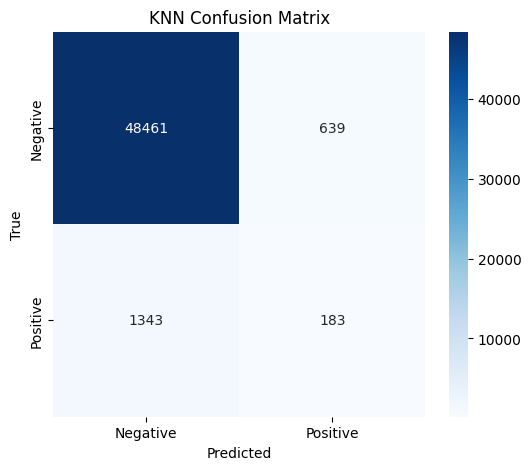

In [ ]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('KNN Confusion Matrix')
plt.show()

# CLUSTERING

## CLUSTERING WITH PCA

In [ ]:
pip install yellowbrick

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 282.6/282.6 kB 4.8 MB/s eta 0:00:00


In [ ]:
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

In [ ]:
# K-Means Clustering
kmeans = KMeans(n_clusters=6, init='k-means++')
kmeans_labels = kmeans.fit_predict(X_pca)

data_new['KMeans_Cluster'] = kmeans_labels

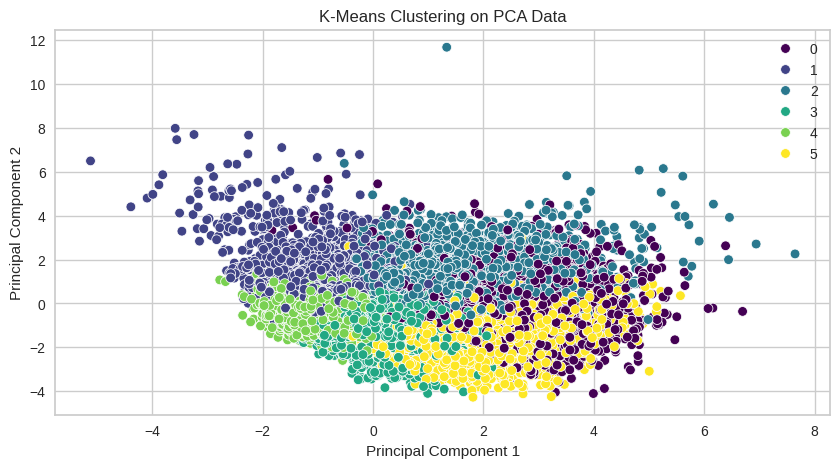

In [ ]:
plt.figure(figsize=(10, 5))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=kmeans_labels, palette="viridis")
plt.title("K-Means Clustering on PCA Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

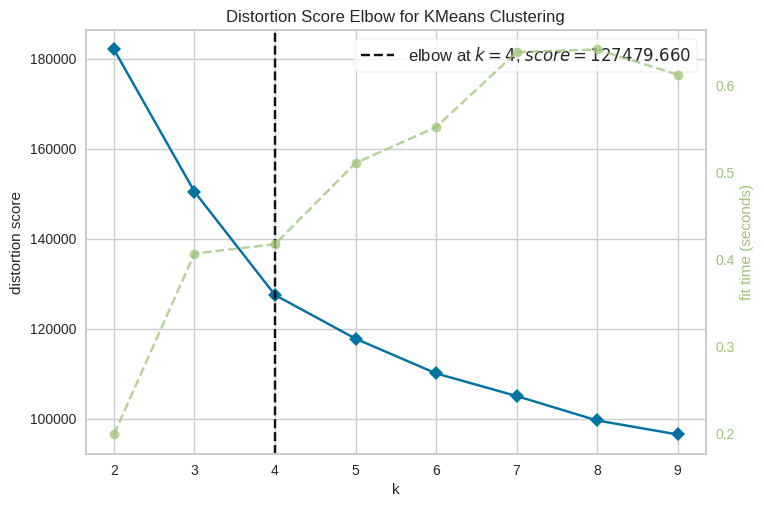

In [ ]:
kmodel = KMeans(random_state=1)
visualizer = KElbowVisualizer(kmodel, k=(2,10))

visualizer.fit(X_pca)
visualizer.show()
plt.show()

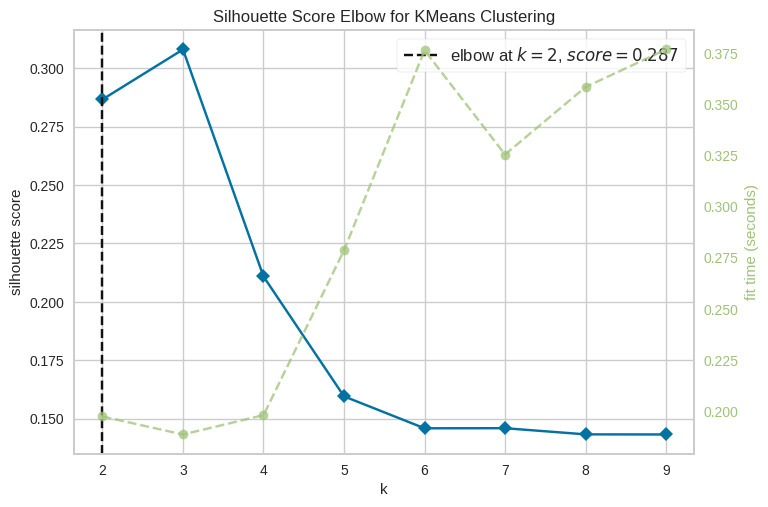

In [ ]:
kmodel = KMeans(random_state=1)
visualizer = KElbowVisualizer(kmodel, k=(2,10), metric='silhouette')

visualizer.fit(X_pca)
visualizer.show()
plt.show()

In [ ]:
KMcluster = KMeans(n_clusters=5, init='k-means++').fit(X_pca) # initialise and fit K-Means model

In [ ]:
KMclustered = pd.DataFrame(X_pca) # Convert X_pca to DataFrame
KMclustered['Cluster'] = KMcluster.labels_ # append labels to points

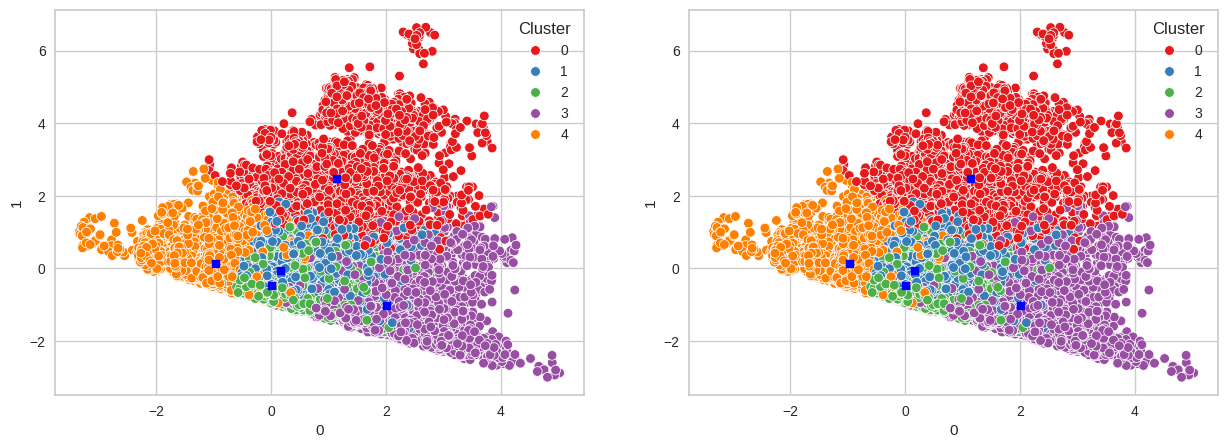

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))  # Create a figure and 2 subplots

# Access the first two columns of KMclustered for plotting
x_col = KMclustered.columns[0]
y_col = KMclustered.columns[1]


scat_1 = sns.scatterplot(x=x_col, y=y_col, data=KMclustered,
                hue='Cluster', ax=axes[0], palette='Set1', legend='full')

sns.scatterplot(x=x_col, y=y_col, data=KMclustered,
                hue='Cluster', palette='Set1', ax=axes[1], legend='full')

axes[0].scatter(KMcluster.cluster_centers_[:, 0], KMcluster.cluster_centers_[:, 1], marker='s', s=40, c="blue")
axes[1].scatter(KMcluster.cluster_centers_[:, 0], KMcluster.cluster_centers_[:, 1], marker='s', s=40, c="blue")
plt.show()

In [ ]:
KM_clust_sizes = KMclustered.groupby('Cluster').size().to_frame()
KM_clust_sizes.columns = ["KM_size"]
KM_clust_sizes

,KM_size
Cluster,
0,3689
1,9459
2,12651
3,3893
4,14593


In [ ]:
from sklearn.cluster import AgglomerativeClustering # Import AgglomerativeClustering

# Remove 'affinity='euclidean'' as it's redundant with 'ward' linkage
hierarchical = AgglomerativeClustering(n_clusters=3, linkage='ward')
hierarchical_labels = hierarchical.fit_predict(X_pca)

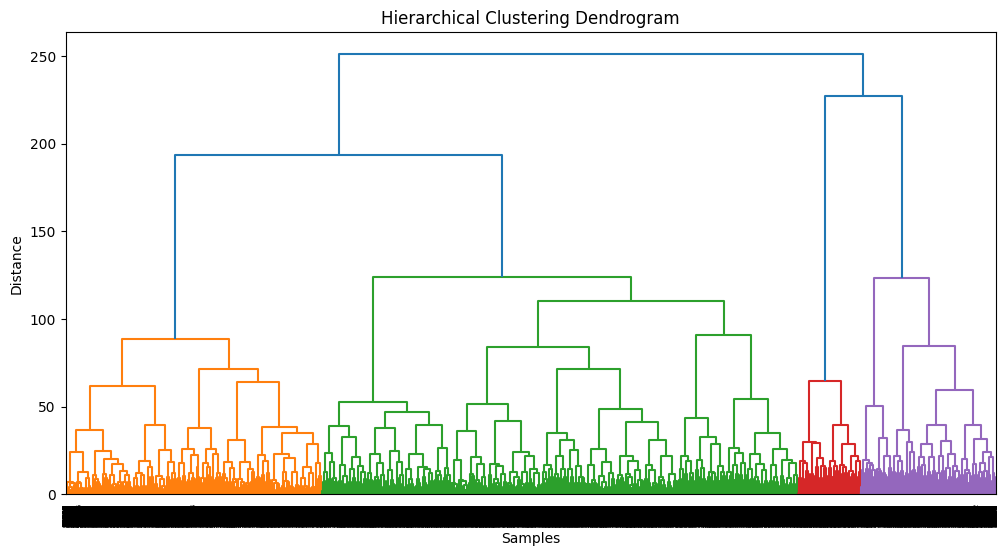

In [ ]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram # Import linkage and dendrogram

plt.figure(figsize=(12, 6))
linked = linkage(X_pca, method='ward')
dendrogram(linked)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

## CLUSTERING WITH KBEST

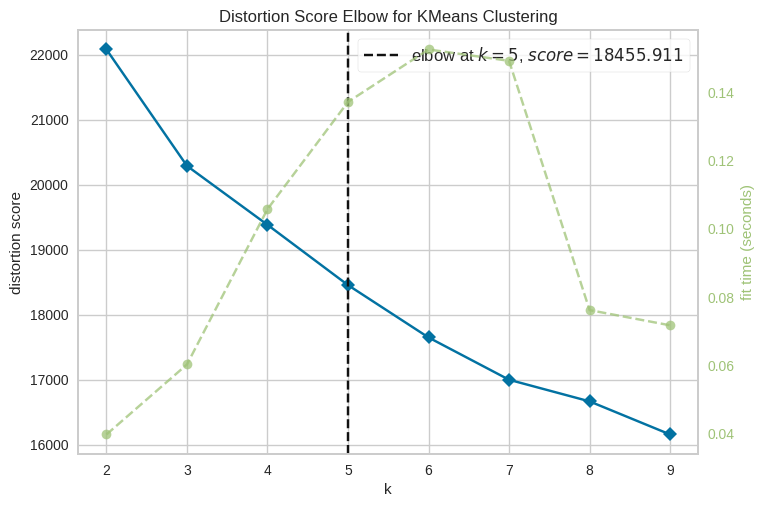

In [ ]:
kmodel = KMeans(random_state=1)
visualizer = KElbowVisualizer(kmodel, k=(2,10))

visualizer.fit(X_kbest)
visualizer.show()
plt.show()

In [ ]:
KMcluster = KMeans(n_clusters=5, init='k-means++').fit(X_kbest) # initialise and fit K-Means model

In [ ]:
KMclustered = pd.DataFrame(X_kbest) # Convert X_pca to DataFrame
KMclustered['Cluster'] = KMcluster.labels_ # append labels to points

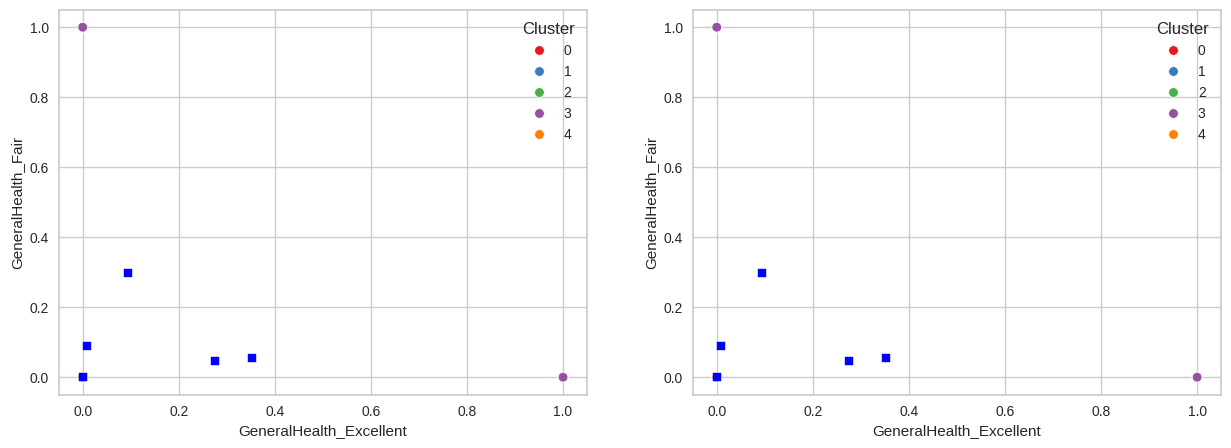

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))  # Create a figure and 2 subplots

# Access the first two columns of KMclustered for plotting
x_col = KMclustered.columns[0]
y_col = KMclustered.columns[1]


scat_1 = sns.scatterplot(x=x_col, y=y_col, data=KMclustered,
                hue='Cluster', ax=axes[0], palette='Set1', legend='full')

sns.scatterplot(x=x_col, y=y_col, data=KMclustered,
                hue='Cluster', palette='Set1', ax=axes[1], legend='full')

axes[0].scatter(KMcluster.cluster_centers_[:, 0], KMcluster.cluster_centers_[:, 1], marker='s', s=40, c="blue")
axes[1].scatter(KMcluster.cluster_centers_[:, 0], KMcluster.cluster_centers_[:, 1], marker='s', s=40, c="blue")
plt.show()

In [ ]:
KM_clust_sizes = KMclustered.groupby('Cluster').size().to_frame()
KM_clust_sizes.columns = ["KM_size"]
KM_clust_sizes

,KM_size
Cluster,
0,1635
1,2187
2,2842
3,2469
4,1792


In [ ]:
!pip install kmodes

In [ ]:
from kmodes.kmodes import KModes

In [ ]:
from kmodes.kmodes import KModes  # Import KModes

# Initialize KModes with 3 clusters and a suitable initialization method
kmodes = KModes(n_clusters=3, init='Huang', n_init=5, verbose=1)

# Fit and predict cluster labels
kmodes_labels = kmodes.fit_predict(X_kbest)

Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 3124, cost: 28146.0
Run 1, iteration: 2/100, moves: 946, cost: 28146.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 2, iteration: 1/100, moves: 3017, cost: 27934.0
Run 2, iteration: 2/100, moves: 667, cost: 27934.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 3, iteration: 1/100, moves: 2486, cost: 28693.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 4, iteration: 1/100, moves: 2934, cost: 27784.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 5, iteration: 1/100, moves: 3289, cost: 30627.0
Run 5, iteration: 2/100, moves: 258, cost: 30596.0
Run 5, iteration: 3/100, moves: 0, cost: 30596.0
Best run was number 4


Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 3610, cost: 31204.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 2, iteration: 1/100, moves: 2456, cost: 28558.0
Run 2, iteration: 2/100, moves: 1096, cost: 28558.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 3, iteration: 1/100, moves: 3598, cost: 28497.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 4, iteration: 1/100, moves: 3372, cost: 29806.0
Run 4, iteration: 2/100, moves: 1339, cost: 29750.0
Run 4, iteration: 3/100, moves: 611, cost: 29750.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 5, iteration: 1/100, moves: 3367, cost: 29500.0
Run 5, iteration: 2/100, moves: 1225, cost: 29500.0
Best run was number 3


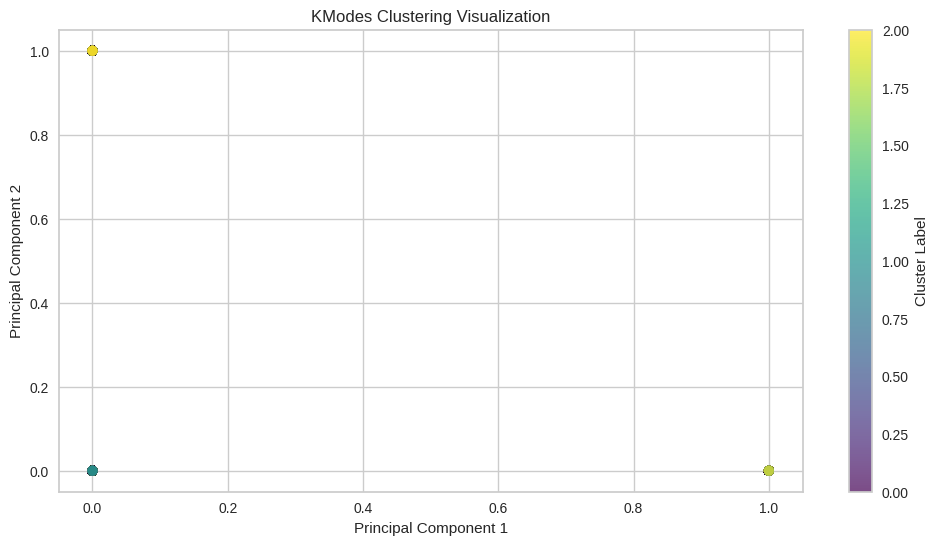

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from kmodes.kmodes import KModes

# Fit KModes clustering
kmodes = KModes(n_clusters=3, init='Huang', n_init=5, verbose=1)
kmodes_labels = kmodes.fit_predict(X_kbest)

# Convert to NumPy array if needed (ensuring compatibility with scatter plot)
X_kbest = np.array(X_kbest)

# Scatter plot for visualization
plt.figure(figsize=(12, 6))
plt.scatter(X_kbest[:, 0], X_kbest[:, 1], c=kmodes_labels, cmap='viridis', alpha=0.7)
plt.title("KModes Clustering Visualization")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Cluster Label")
plt.show()
